<a href="https://colab.research.google.com/github/apy9955/customer-segmentation-system/blob/main/Customer_Segmentation_Using_K_Means_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [37]:
from google.colab import files
uploaded = files.upload()

Saving Mall_Customers.csv to Mall_Customers (1).csv


In [38]:
df = pd.read_csv('Mall_Customers.csv')

In [39]:
df.head(10)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


In [40]:
df.tail(10)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
190,191,Female,34,103,23
191,192,Female,32,103,69
192,193,Male,33,113,8
193,194,Female,38,113,91
194,195,Female,47,120,16
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18
199,200,Male,30,137,83


In [41]:
df.shape

(200, 5)

In [42]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [43]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [44]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [45]:
df.duplicated().sum()

np.int64(0)

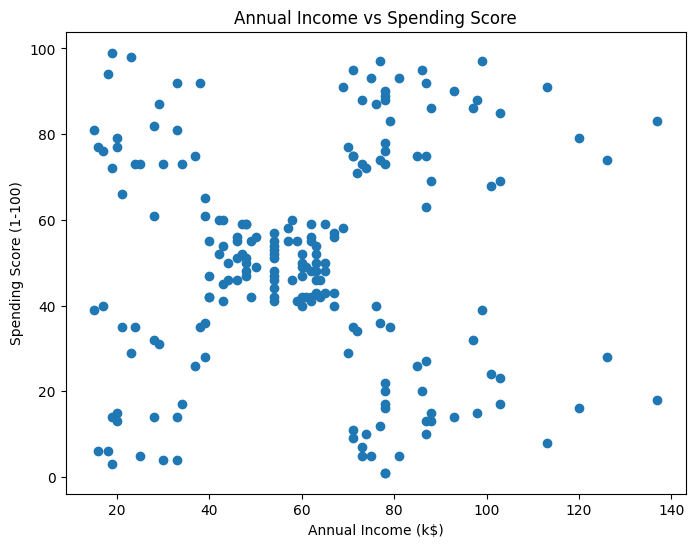

In [46]:
plt.figure(figsize=(8,6))

plt.scatter(df['Annual Income (k$)'],
            df['Spending Score (1-100)'])

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Annual Income vs Spending Score')

plt.show()

In [47]:
import matplotlib.pyplot as plt

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

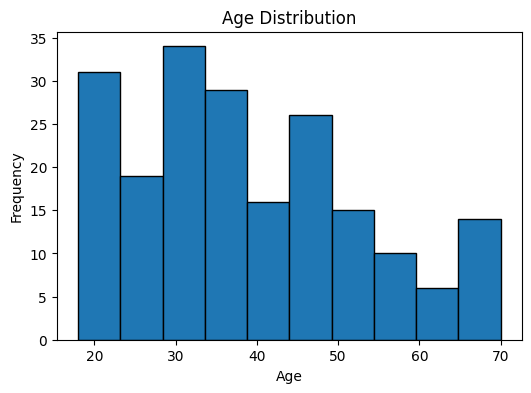

In [49]:
plt.figure(figsize=(6,4))
plt.hist(df['Age'], bins=10, edgecolor='black')

plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.show()

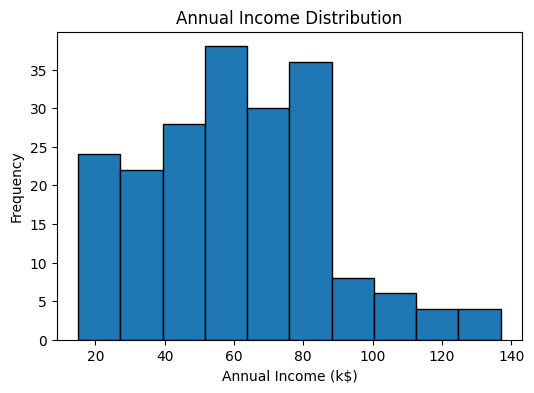

In [50]:
plt.figure(figsize=(6,4))
plt.hist(df['Annual Income (k$)'], bins=10, edgecolor='black')

plt.title('Annual Income Distribution')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Frequency')

plt.show()

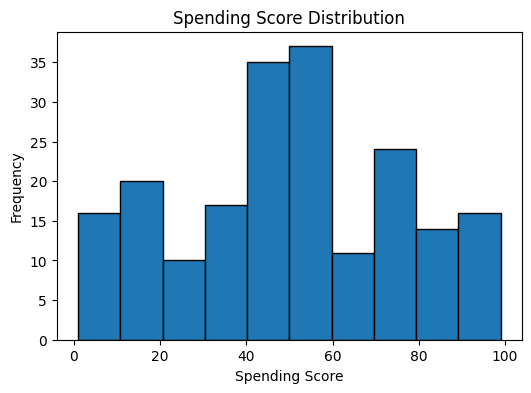

In [51]:
plt.figure(figsize=(6,4))
plt.hist(df['Spending Score (1-100)'], bins=10, edgecolor='black')

plt.title('Spending Score Distribution')
plt.xlabel('Spending Score')
plt.ylabel('Frequency')

plt.show()

In [52]:
df.corr(numeric_only=True)

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
CustomerID,1.000000,-0.026763,0.977548,0.013835
Age,-0.026763,1.000000,-0.012398,-0.327227
Annual Income (k$),0.977548,-0.012398,1.000000,0.009903
Spending Score (1-100),0.013835,-0.327227,0.009903,1.000000


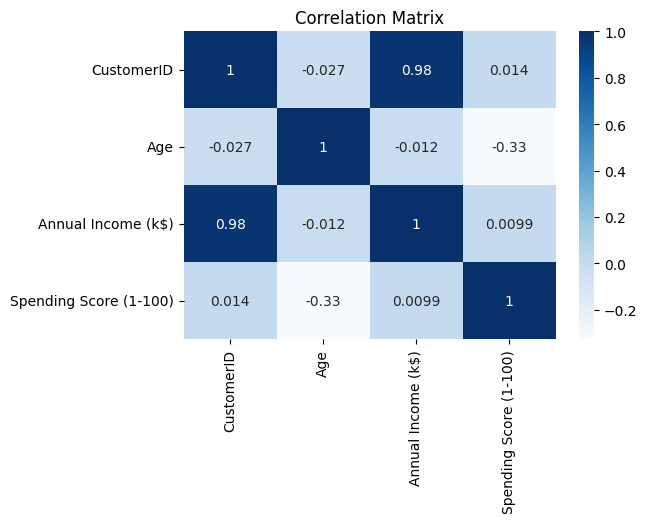

In [53]:
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='Blues')

plt.title('Correlation Matrix')
plt.show()

In [54]:
# Selecting features for clustering

X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [55]:
# Elbow Method

wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i,
                    init='k-means++',
                    random_state=42)

    kmeans.fit(X)

    wcss.append(kmeans.inertia_)

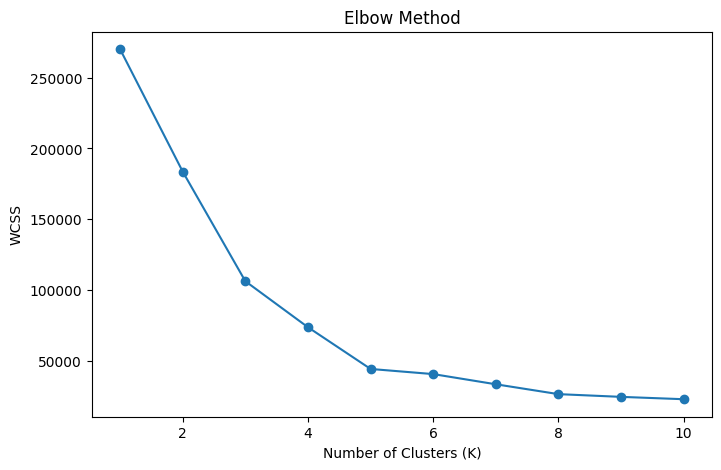

In [56]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title('Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')

plt.show()

In [57]:
# Building the K-Means Model

kmeans = KMeans(
    n_clusters=5,
    init='k-means++',
    random_state=42,
    n_init=10
)

kmeans.fit(X)

KMeans(n_clusters=5, n_init=10, random_state=42)

In [58]:
# Assigning cluster labels

df['Cluster'] = kmeans.fit_predict(X)

In [59]:
df.head(10)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4
5,6,Female,22,17,76,2
6,7,Female,35,18,6,4
7,8,Female,23,18,94,2
8,9,Male,64,19,3,4
9,10,Female,30,19,72,2


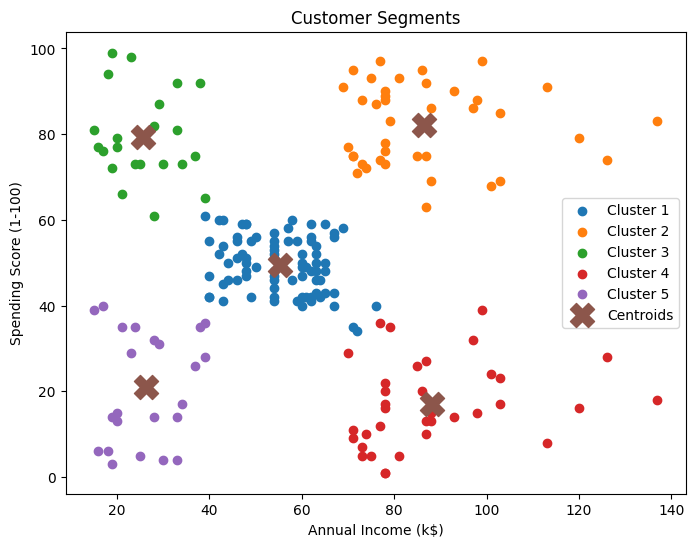

In [60]:
plt.figure(figsize=(8,6))

plt.scatter(
    X[df['Cluster']==0]['Annual Income (k$)'],
    X[df['Cluster']==0]['Spending Score (1-100)'],
    label='Cluster 1'
)

plt.scatter(
    X[df['Cluster']==1]['Annual Income (k$)'],
    X[df['Cluster']==1]['Spending Score (1-100)'],
    label='Cluster 2'
)

plt.scatter(
    X[df['Cluster']==2]['Annual Income (k$)'],
    X[df['Cluster']==2]['Spending Score (1-100)'],
    label='Cluster 3'
)

plt.scatter(
    X[df['Cluster']==3]['Annual Income (k$)'],
    X[df['Cluster']==3]['Spending Score (1-100)'],
    label='Cluster 4'
)

plt.scatter(
    X[df['Cluster']==4]['Annual Income (k$)'],
    X[df['Cluster']==4]['Spending Score (1-100)'],
    label='Cluster 5'
)

# Centroids
plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    s=300,
    marker='X',
    label='Centroids'
)

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Segments')
plt.legend()

plt.show()

In [61]:
cluster_names = {
    0: "Medium Value Customer",
    1: "High Value Customer",
    2: "Potential Customer",
    3: "Low Value Customer",
    4: "Budget Customer"
}

In [62]:
prediction = kmeans.predict([[income, score]])

print(cluster_names[prediction[0]])

High Value Customer


In [63]:
income = float(input("Enter Annual Income: "))
score = float(input("Enter Spending Score: "))

prediction = kmeans.predict([[income, score]])

print("Customer Type:")
print(cluster_names[prediction[0]])

Enter Annual Income: 120000
Enter Spending Score: 10000
Customer Type:
High Value Customer


In [64]:
model = pickle.load(open('kmeans_model.pkl', 'rb'))

In [65]:
from google.colab import files

files.download("kmeans_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [66]:
files.download("Mall_Customers.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>